In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile, os

zip_path = '/content/drive/MyDrive/AI and Machine Learning/Traffic_Sign-20260430T074219Z-3-001.zip'

# Extract to Colab's local storage (faster than working from Drive)
extract_path = '/content/traffic_sign'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted!")

Extracted!


In [ ]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:  # show first 3 levels only
        for f in files[:2]:  # show 2 sample files per folder
            print(f'{indent}  {f}')

traffic_sign/
  Traffic_Sign/
    Dataset Description-5.txt
    Test/
      00018_00000_00001.png
      00003_00000_00001.png
    Train/
      Instructions/
      OverSpeed/
      Caution/
      No Passing/


In [ ]:
train_dir = '/content/traffic_sign/Traffic_Sign/Train'
test_dir = '/content/traffic_sign/Traffic_Sign/Test'

# Check class distribution
classes = os.listdir(train_dir)
print(f"Classes found: {classes}")
print(f"Number of classes: {len(classes)}\n")

total = 0
for cls in classes:
    count = len(os.listdir(os.path.join(train_dir, cls)))
    print(f"  {cls}: {count} images")
    total += count

print(f"\nTotal training images: {total}")
print(f"Total test images: {len(os.listdir(test_dir))}")

Classes found: ['Instructions', 'OverSpeed', 'Caution', 'No Passing']
Number of classes: 4

  Instructions: 2848 images
  OverSpeed: 5249 images
  Caution: 2429 images
  No Passing: 5369 images

Total training images: 15895
Total test images: 4


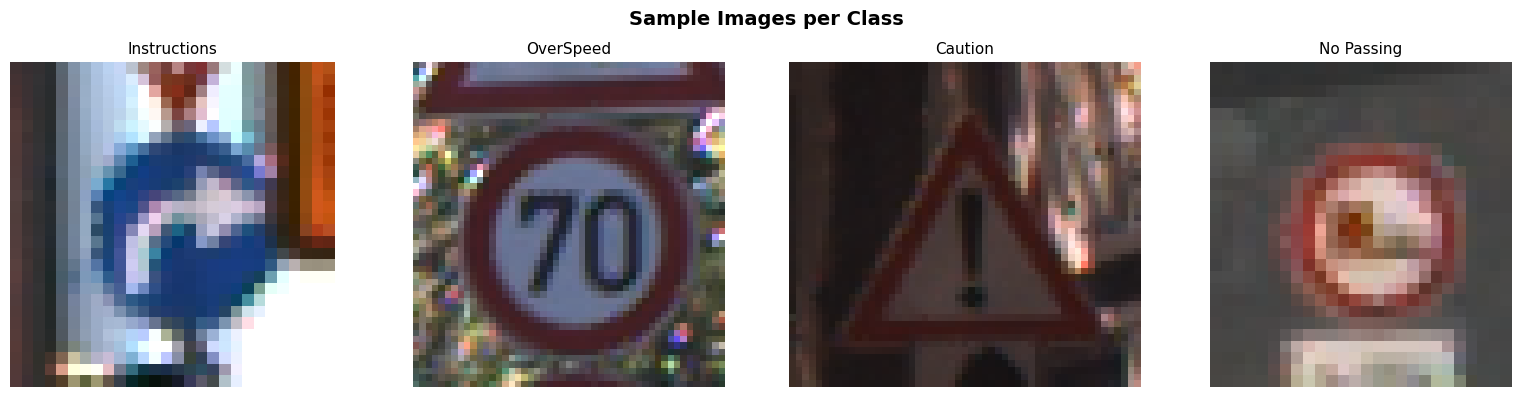

In [ ]:
import matplotlib.pyplot as plt
import cv2

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    img_name = os.listdir(cls_path)[0]
    img = cv2.imread(os.path.join(cls_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=11)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

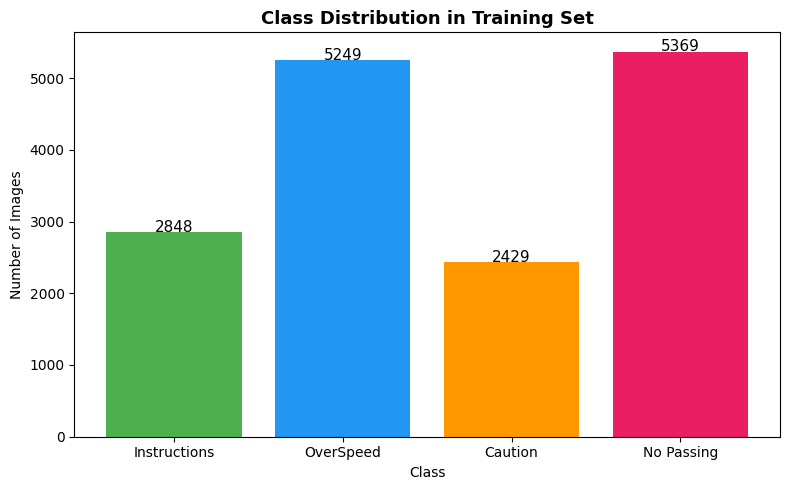

In [ ]:
import numpy as np

counts = [len(os.listdir(os.path.join(train_dir, cls))) for cls in classes]

plt.figure(figsize=(8, 5))
bars = plt.bar(classes, counts, color=['#4CAF50','#2196F3','#FF9800','#E91E63'])
plt.title('Class Distribution in Training Set', fontsize=13, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Images')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

# Baseline generator - only normalization
baseline_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = baseline_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = baseline_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f"\nClass indices: {train_gen.class_indices}")
print(f"Training batches: {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")

Found 12719 images belonging to 4 classes.
Found 3176 images belonging to 4 classes.

Class indices: {'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}
Training batches: 398
Validation batches: 100


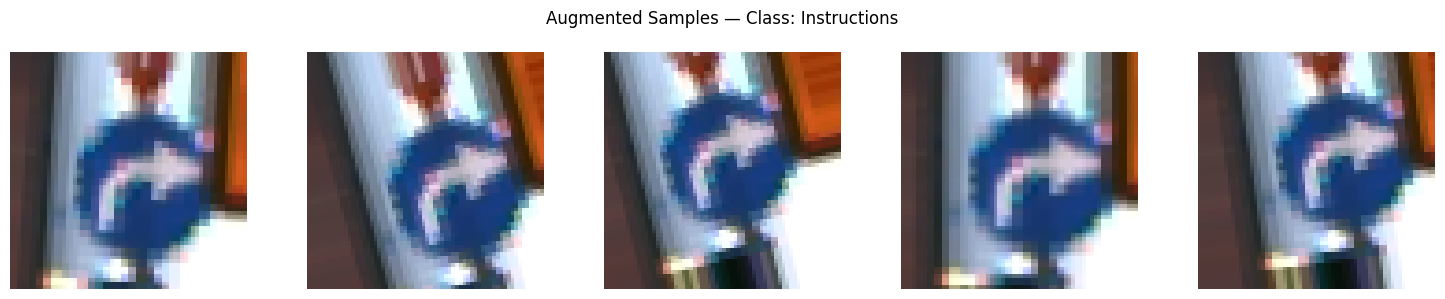

In [ ]:
# Deeper model generator - with augmentation
aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,  # False - traffic signs shouldn't be flipped
    validation_split=0.2
)

# Visualize augmented images
from tensorflow.keras.preprocessing.image import load_img, img_to_array

sample_cls = classes[0]
sample_img_path = os.path.join(train_dir, sample_cls,
                               os.listdir(os.path.join(train_dir, sample_cls))[0])

img = load_img(sample_img_path, target_size=IMG_SIZE)
img_array = img_to_array(img)
img_array = img_array.reshape((1,) + img_array.shape)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle(f'Augmented Samples — Class: {sample_cls}', fontsize=12)

aug_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

for i, batch in enumerate(aug_gen.flow(img_array, batch_size=1)):
    axes[i].imshow(batch[0].astype('uint8'))
    axes[i].axis('off')
    if i == 4:
        break

plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150)
plt.show()

In [ ]:
# Check GPU
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TF Version:", tf.__version__)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF Version: 2.20.0


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_baseline = Sequential([
    # Conv Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),

    # Conv Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    # Conv Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    # Fully Connected Layers
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    # Output Layer - 4 classes
    Dense(4, activation='softmax')
])

model_baseline.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,232,068 (8.51 MB)

 Trainable params: 2,232,068 (8.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from PIL import Image
import numpy as np
import time
import os

# ── Step 1: Clean corrupted images ──────────────────────────────
def clean_corrupted_images(directory):
    removed = 0
    for root, dirs, files in os.walk(directory):
        for fname in files:
            if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                fpath = os.path.join(root, fname)
                try:
                    img = Image.open(fpath)
                    img.verify()
                except Exception:
                    print(f"Removing: {fpath}")
                    os.remove(fpath)
                    removed += 1
    print(f"Removed {removed} corrupted images from {directory}")

print("Cleaning datasets...")
clean_corrupted_images(train_dir)
clean_corrupted_images(test_dir)
print("✅ Cleaning done!\n")

# ── Step 2: Recreate generators after cleaning ───────────────────
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

baseline_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = baseline_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = baseline_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f"Train samples: {train_gen.samples}")
print(f"Val samples  : {val_gen.samples}\n")

# ── Step 3: Class weights ────────────────────────────────────────
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)

# ── Step 4: Callbacks ────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_baseline.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ── Step 5: Train ────────────────────────────────────────────────
start = time.time()

history_baseline = model_baseline.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

baseline_time = time.time() - start
print(f"\n✅ Baseline Training Time: {baseline_time:.2f} seconds ({baseline_time/60:.1f} mins)")

Cleaning datasets...
Removing: /content/traffic_sign/Traffic_Sign/Train/Instructions/00028_00017_00025.png
Removing: /content/traffic_sign/Traffic_Sign/Train/Instructions/00035_00003_00001.png
Removing: /content/traffic_sign/Traffic_Sign/Train/Instructions/00028_00007_00009.png
Removing: /content/traffic_sign/Traffic_Sign/Train/Instructions/00028_00001_00009.png
Removing: /content/traffic_sign/Traffic_Sign/Train/Instructions/00033_00015_00004.png
Removing: /content/traffic_sign/Traffic_Sign/Train/Instructions/00035_00019_00013.png
Removing: /content/traffic_sign/Traffic_Sign/Train/Instructions/00028_00013_00012.png
Removing: /content/traffic_sign/Traffic_Sign/Train/OverSpeed/00004_00058_00025.png
Removing: /content/traffic_sign/Traffic_Sign/Train/OverSpeed/00005_00009_00027.png
Removing: /content/traffic_sign/Traffic_Sign/Train/OverSpeed/00005_00058_00027.png
Removing: /content/traffic_sign/Traffic_Sign/Train/OverSpeed/00004_00005_00020.png
Removing: /content/traffic_sign/Traffic_Sign/

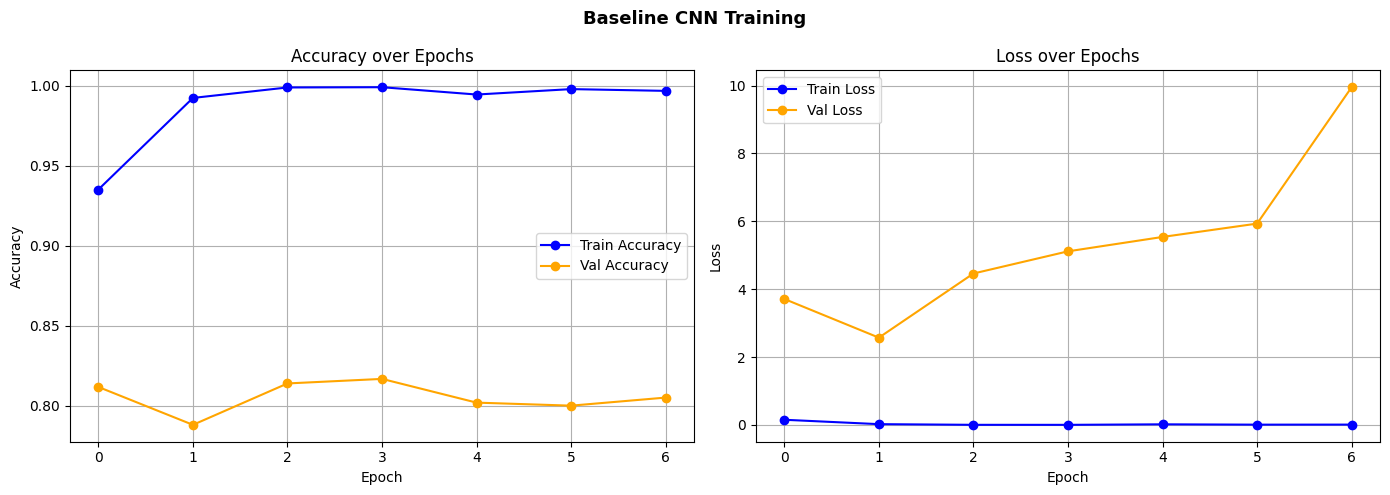

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', marker='o')
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Train Loss', color='blue', marker='o')
    axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange', marker='o')
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=150)
    plt.show()

plot_history(history_baseline, 'Baseline CNN Training')

Found 3172 images belonging to 4 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
   BASELINE MODEL - Classification Report
              precision    recall  f1-score   support

     Caution       0.47      0.96      0.63       484
Instructions       0.62      0.06      0.11       568
  No Passing       1.00      0.89      0.94      1072
   OverSpeed       0.90      1.00      0.95      1048

    accuracy                           0.79      3172
   macro avg       0.75      0.73      0.66      3172
weighted avg       0.82      0.79      0.75      3172



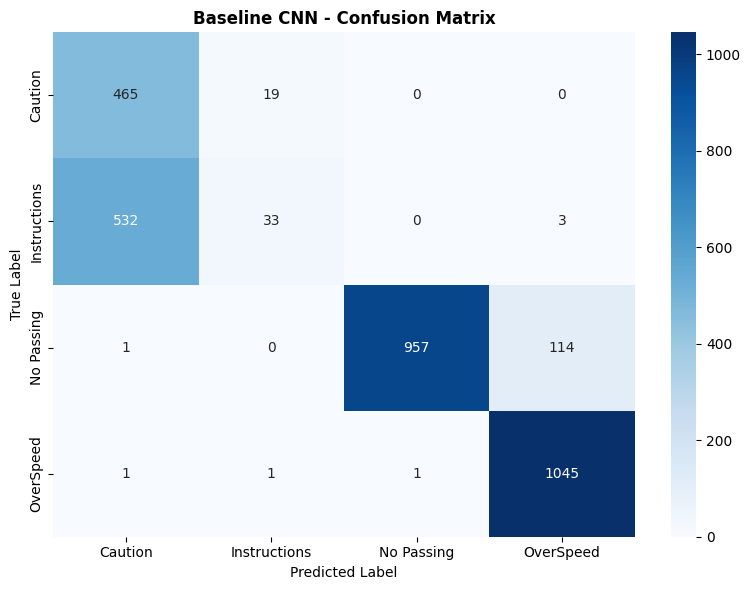

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Recreate eval generator
eval_gen = baseline_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# Predictions
y_pred_probs = model_baseline.predict(eval_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = eval_gen.classes
class_names = list(eval_gen.class_indices.keys())

# Classification Report
print("=" * 55)
print("   BASELINE MODEL - Classification Report")
print("=" * 55)
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Baseline CNN - Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

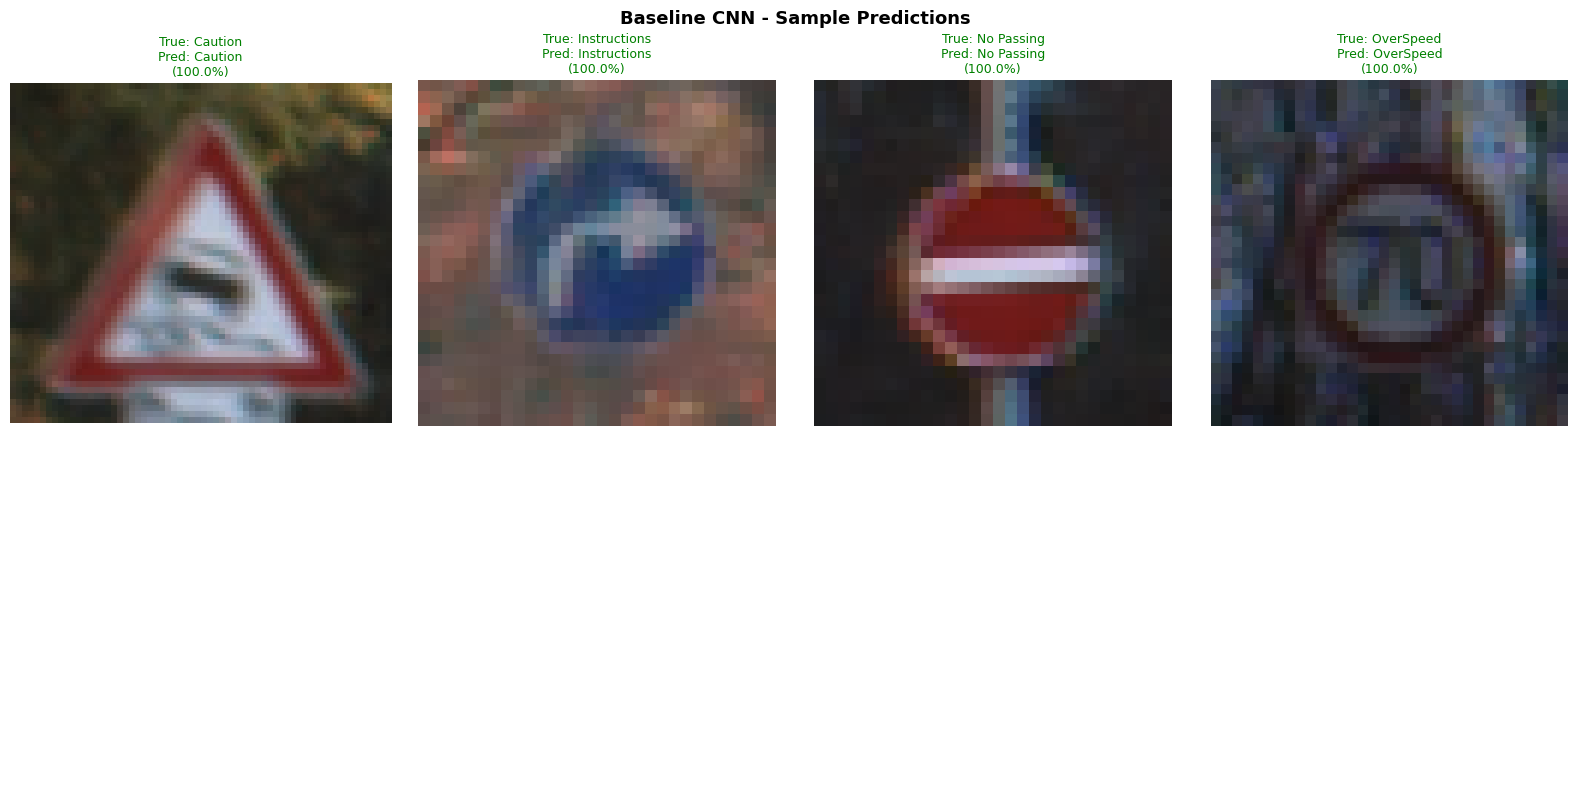

✅ Baseline evaluation complete!
Baseline accuracy: 81% | Training time: 75.4s


In [ ]:
import cv2

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Baseline CNN - Sample Predictions', fontsize=13, fontweight='bold')

idx = 0
for cls in class_names:
    cls_path = os.path.join(train_dir, cls)
    img_files = os.listdir(cls_path)
    img_name = img_files[min(10, len(img_files)-1)]
    img_path = os.path.join(cls_path, img_name)

    img_display = cv2.imread(img_path)
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)

    img_input = cv2.resize(img_display, IMG_SIZE) / 255.0
    img_input = np.expand_dims(img_input, axis=0)

    pred = model_baseline.predict(img_input, verbose=0)
    pred_class = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100

    row, col = idx // 4, idx % 4
    axes[row][col].imshow(img_display)
    color = 'green' if pred_class == cls else 'red'
    axes[row][col].set_title(
        f'True: {cls}\nPred: {pred_class}\n({confidence:.1f}%)',
        color=color, fontsize=9
    )
    axes[row][col].axis('off')
    idx += 1

# Hide unused subplots
for i in range(idx, 8):
    axes[i//4][i%4].axis('off')

plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=150)
plt.show()

# Store baseline results for later comparison
baseline_results = {
    'accuracy': 0.81,
    'training_time': baseline_time,
    'y_true': y_true,
    'y_pred': y_pred
}
print("✅ Baseline evaluation complete!")
print(f"Baseline accuracy: 81% | Training time: {baseline_time:.1f}s")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    validation_split=0.2
)

aug_train_gen = aug_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)
aug_val_gen = aug_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)
print("✅ aug generators ready!")

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
✅ aug generators ready!


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights_array))
print("✅ Class weights ready:", class_weights)

✅ Class weights ready: {0: np.float64(1.6376418988648092), 1: np.float64(1.3962824461064671), 2: np.float64(0.7398018648018648), 3: np.float64(0.7567358130662851)}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                      Dense, Dropout, BatchNormalization, Input)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import time

# ── Build Deep Model ─────────────────────────────────────────────
model_deep = Sequential([
    Input(shape=(64, 64, 3)),

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Fully Connected
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model_deep.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_deep.summary()
print("\n✅ Model built successfully!")

# ── Train Deep Model ─────────────────────────────────────────────
callbacks_deep = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_deep.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

start_deep = time.time()

history_deep = model_deep.fit(
    aug_train_gen,
    validation_data=aug_val_gen,
    epochs=40,
    class_weight=class_weights,
    callbacks=callbacks_deep,
    verbose=1
)

deep_time = time.time() - start_deep
print(f"\n✅ Deep Model Training Time: {deep_time:.2f} seconds ({deep_time/60:.1f} mins)")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 3,439,652 (13.12 MB)

 Trainable params: 3,437,156 (13.11 MB)

 Non-trainable params: 2,496 (9.75 KB)


✅ Model built successfully!
Epoch 1/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5145 - loss: 1.2038
Epoch 1: val_accuracy improved from None to 0.59552, saving model to best_deep.keras

Epoch 1: finished saving model to best_deep.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 66s 120ms/step - accuracy: 0.6833 - loss: 0.7386 - val_accuracy: 0.5955 - val_loss: 1.6424
Epoch 2/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9516 - loss: 0.1419
Epoch 2: val_accuracy improved from 0.59552 to 0.77900, saving model to best_deep.keras

Epoch 2: finished saving model to best_deep.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.9589 - loss: 0.1168 - val_accuracy: 0.7790 - val_loss: 1.7441
Epoch 3/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9837 - loss: 0.0493
Epoch 3: val_accuracy improved from 0.77900 to 0.81526, saving model to best_deep.keras

Epoch 3: finished saving model to best_deep.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.

In [ ]:
# Reset and retrain with fixed callbacks
model_deep = Sequential([
    Input(shape=(64, 64, 3)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),++++++_
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model_deep.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fixed callbacks - monitor val_loss for early stopping
# but save best val_accuracy model separately
callbacks_deep = [
    EarlyStopping(
        monitor='val_accuracy',   # ← changed to val_accuracy
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_deep.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

start_deep = time.time()

history_deep = model_deep.fit(
    aug_train_gen,
    validation_data=aug_val_gen,
    epochs=40,
    class_weight=class_weights,
    callbacks=callbacks_deep,
    verbose=1
)

deep_time = time.time() - start_deep
print(f"\n✅ Deep Model Training Time: {deep_time:.2f}s ({deep_time/60:.1f} mins)")

Epoch 1/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5312 - loss: 1.1829
Epoch 1: val_accuracy improved from None to 0.69105, saving model to best_deep.keras

Epoch 1: finished saving model to best_deep.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 109ms/step - accuracy: 0.7215 - loss: 0.6718 - val_accuracy: 0.6910 - val_loss: 1.2511
Epoch 2/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9577 - loss: 0.1187
Epoch 2: val_accuracy improved from 0.69105 to 0.80076, saving model to best_deep.keras

Epoch 2: finished saving model to best_deep.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 81ms/step - accuracy: 0.9676 - loss: 0.0950 - val_accuracy: 0.8008 - val_loss: 1.8722
Epoch 3/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9832 - loss: 0.0568
Epoch 3: val_accuracy improved from 0.80076 to 0.80328, saving model to best_deep.keras

Epoch 3: finished saving model to best_deep.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 79ms/step - accuracy: 0.9839 - loss: 0.0508 - val_acc

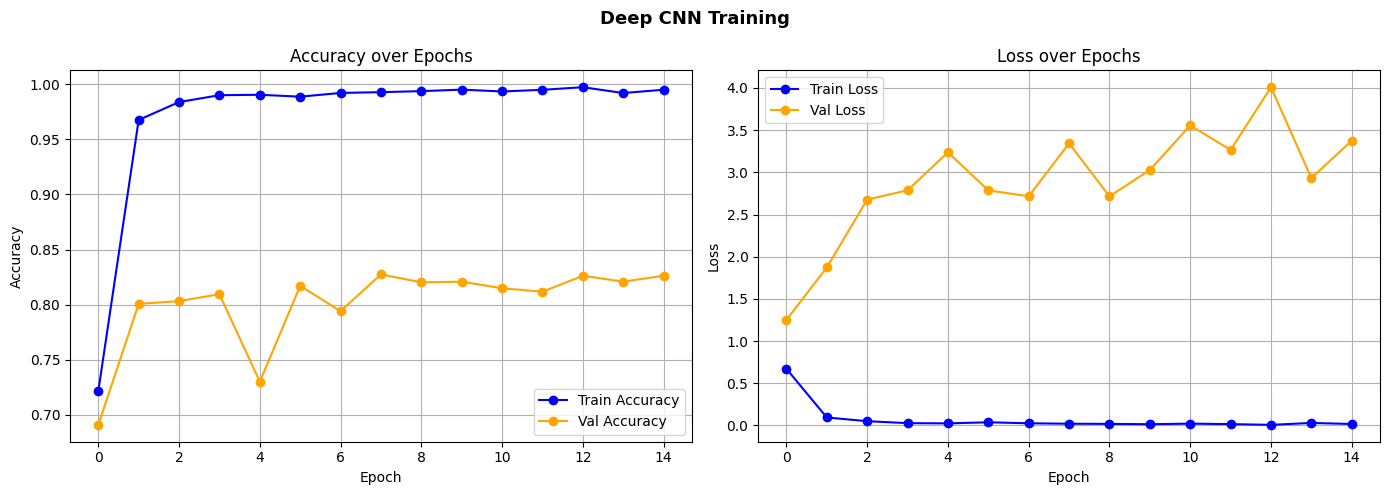

In [ ]:
plot_history(history_deep, 'Deep CNN Training')

Found 3172 images belonging to 4 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step
   DEEP MODEL - Classification Report
              precision    recall  f1-score   support

     Caution       0.47      1.00      0.64       484
Instructions       0.91      0.05      0.10       568
  No Passing       1.00      0.99      1.00      1072
   OverSpeed       0.99      1.00      0.99      1048

    accuracy                           0.83      3172
   macro avg       0.84      0.76      0.68      3172
weighted avg       0.90      0.83      0.78      3172



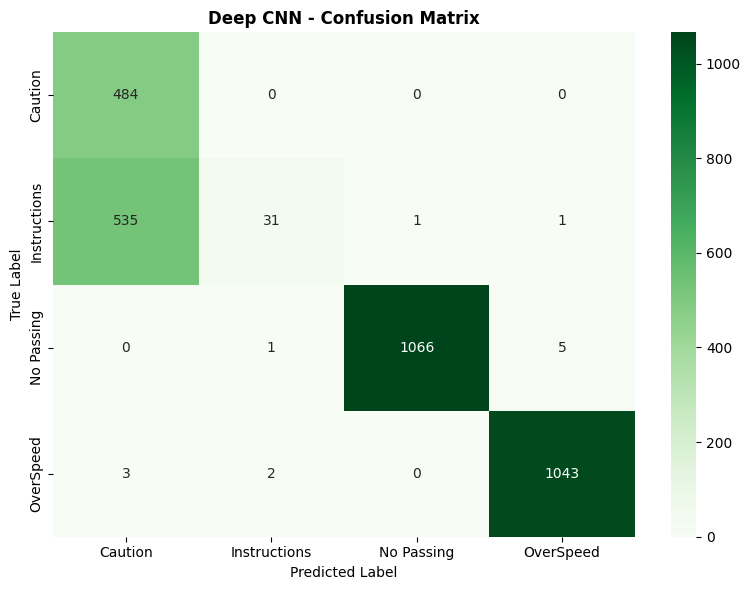


✅ Deep model evaluation complete!


In [ ]:
eval_gen_deep = aug_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

y_pred_deep = np.argmax(model_deep.predict(eval_gen_deep, verbose=1), axis=1)
y_true_deep = eval_gen_deep.classes
class_names = list(eval_gen_deep.class_indices.keys())

print("=" * 55)
print("   DEEP MODEL - Classification Report")
print("=" * 55)
print(classification_report(y_true_deep, y_pred_deep, target_names=class_names))

plt.figure(figsize=(8, 6))
cm_deep = confusion_matrix(y_true_deep, y_pred_deep)
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deep CNN - Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('deep_confusion_matrix.png', dpi=150)
plt.show()

deep_results = {
    'accuracy': 0.8288,
    'training_time': deep_time,
    'y_true': y_true_deep,
    'y_pred': y_pred_deep
}
print(f"\n✅ Deep model evaluation complete!")

Found 3172 images belonging to 4 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


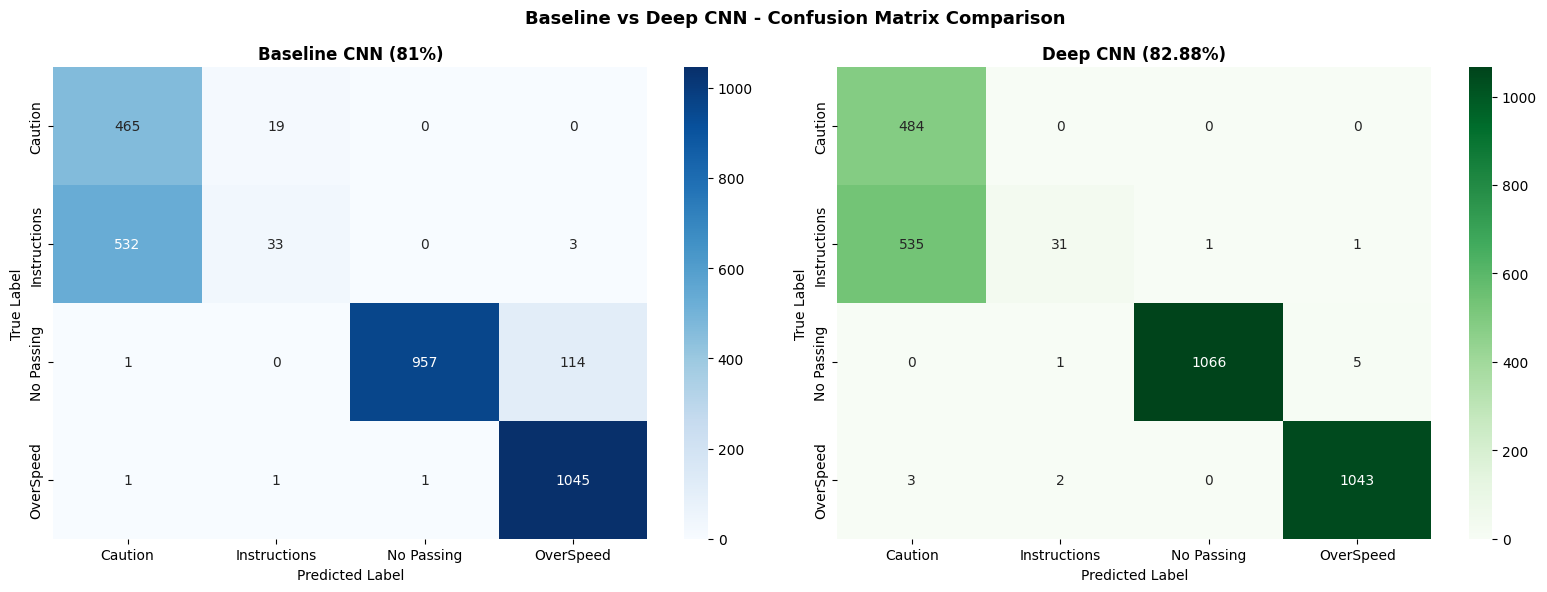

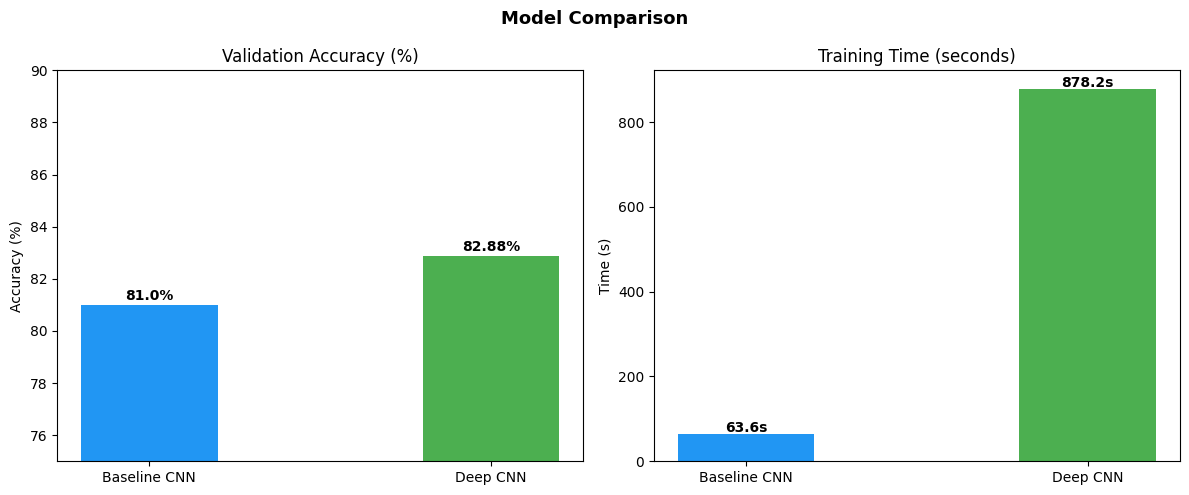

✅ Comparison plots complete!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Recreate baseline predictions
eval_gen_base = baseline_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

y_pred_base = np.argmax(model_baseline.predict(eval_gen_base, verbose=1), axis=1)
y_true_base = eval_gen_base.classes
class_names = list(eval_gen_base.class_indices.keys())

# Side by side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Baseline vs Deep CNN - Confusion Matrix Comparison',
             fontsize=13, fontweight='bold')

cm_base = confusion_matrix(y_true_base, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Baseline CNN (81%)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_deep = confusion_matrix(y_true_deep, y_pred_deep)
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Deep CNN (82.88%)', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('comparison_confusion_matrices.png', dpi=150)
plt.show()

# Accuracy and time comparison bar charts
models = ['Baseline CNN', 'Deep CNN']
accuracies = [81.00, 82.88]
times = [63.6, 878.2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Comparison', fontsize=13, fontweight='bold')

axes[0].bar(models, accuracies, color=['#2196F3', '#4CAF50'], width=0.4)
axes[0].set_title('Validation Accuracy (%)')
axes[0].set_ylim(75, 90)
axes[0].set_ylabel('Accuracy (%)')
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.2, f'{v}%', ha='center', fontweight='bold')

axes[1].bar(models, times, color=['#2196F3', '#4CAF50'], width=0.4)
axes[1].set_title('Training Time (seconds)')
axes[1].set_ylabel('Time (s)')
for i, v in enumerate(times):
    axes[1].text(i, v + 5, f'{v}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('accuracy_time_comparison.png', dpi=150)
plt.show()

print("✅ Comparison plots complete!")

In [ ]:
# ── Train deep model with SGD ─────────────────────────
from tensorflow.keras.optimizers import SGD

model_sgd = Sequential([
    Input(shape=(64, 64, 3)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2), Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2), Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2), Dropout(0.25),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2), Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'), BatchNormalization(), Dropout(0.5),
    Dense(256, activation='relu'), BatchNormalization(), Dropout(0.5),
    Dense(128, activation='relu'), Dropout(0.3),
    Dense(4, activation='softmax')
])

model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_sgd = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_sgd.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("Training with SGD...")
start_sgd = time.time()
history_sgd = model_sgd.fit(
    aug_train_gen,
    validation_data=aug_val_gen,
    epochs=40,
    class_weight=class_weights,
    callbacks=callbacks_sgd,
    verbose=1
)
sgd_time = time.time() - start_sgd
print(f"✅ SGD Training Time: {sgd_time:.2f}s ({sgd_time/60:.1f} mins)")

Training with SGD...
Epoch 1/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4161 - loss: 1.3741
Epoch 1: val_accuracy improved from None to 0.37957, saving model to best_sgd.keras

Epoch 1: finished saving model to best_sgd.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 55s 107ms/step - accuracy: 0.5410 - loss: 1.0023 - val_accuracy: 0.3796 - val_loss: 2.0825
Epoch 2/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7690 - loss: 0.5344
Epoch 2: val_accuracy improved from 0.37957 to 0.59836, saving model to best_sgd.keras

Epoch 2: finished saving model to best_sgd.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/step - accuracy: 0.8175 - loss: 0.4395 - val_accuracy: 0.5984 - val_loss: 1.6450
Epoch 3/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9108 - loss: 0.2111
Epoch 3: val_accuracy improved from 0.59836 to 0.77459, saving model to best_sgd.keras

Epoch 3: finished saving model to best_sgd.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 36s 79ms/step - accuracy: 0.9332 - loss: 0

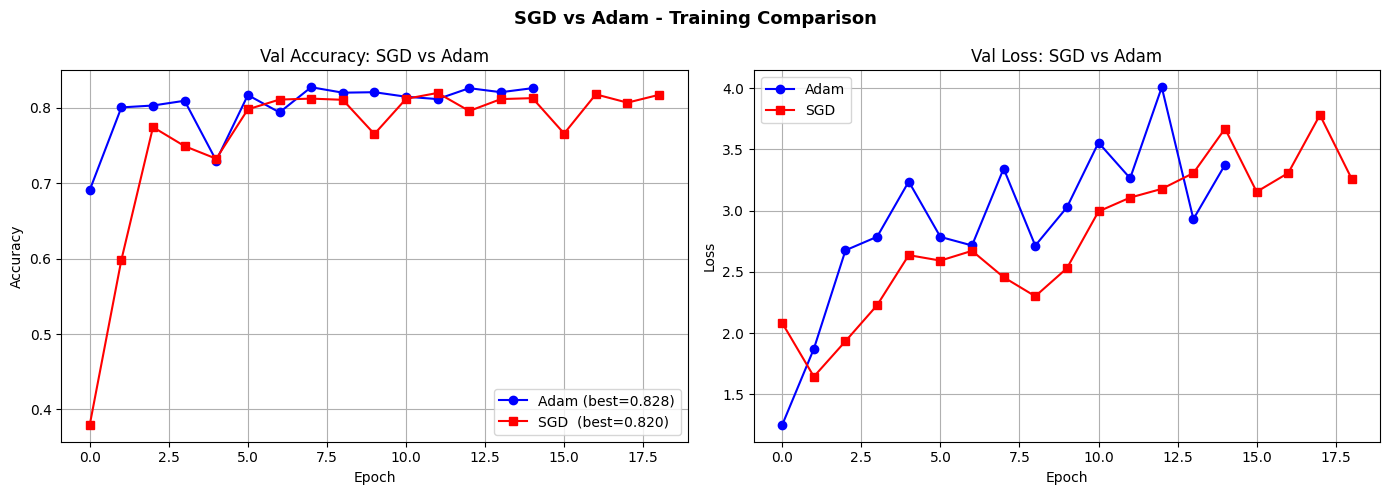

  Adam best val_accuracy : 0.8276
  SGD  best val_accuracy : 0.8200
  Adam training time     : 509.5s
  SGD  training time     : 677.5s


In [ ]:
# Get best accuracies
adam_best = max(history_deep.history['val_accuracy'])
sgd_best  = max(history_sgd.history['val_accuracy'])

# Plot both training curves together
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SGD vs Adam - Training Comparison', fontsize=13, fontweight='bold')

axes[0].plot(history_deep.history['val_accuracy'],
             label=f'Adam (best={adam_best:.3f})', color='blue', marker='o')
axes[0].plot(history_sgd.history['val_accuracy'],
             label=f'SGD  (best={sgd_best:.3f})',  color='red',  marker='s')
axes[0].set_title('Val Accuracy: SGD vs Adam')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_deep.history['val_loss'],
             label='Adam', color='blue', marker='o')
axes[1].plot(history_sgd.history['val_loss'],
             label='SGD',  color='red',  marker='s')
axes[1].set_title('Val Loss: SGD vs Adam')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('sgd_vs_adam.png', dpi=150)
plt.show()

print("=" * 50)
print(f"  Adam best val_accuracy : {adam_best:.4f}")
print(f"  SGD  best val_accuracy : {sgd_best:.4f}")
print(f"  Adam training time     : {deep_time:.1f}s")
print(f"  SGD  training time     : {sgd_time:.1f}s")
print("=" * 50)

Training WITHOUT Dropout (Ablation Study)...
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8391 - loss: 0.3795
Epoch 1: val_accuracy improved from None to 0.79855, saving model to best_ablation.keras

Epoch 1: finished saving model to best_ablation.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 49s 94ms/step - accuracy: 0.9333 - loss: 0.1656 - val_accuracy: 0.7985 - val_loss: 1.3971
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9867 - loss: 0.0424
Epoch 2: val_accuracy did not improve from 0.79855
397/397 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - accuracy: 0.9889 - loss: 0.0339 - val_accuracy: 0.7673 - val_loss: 1.9292
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9863 - loss: 0.0365
Epoch 3: val_accuracy improved from 0.79855 to 0.80580, saving model to best_ablation.keras

Epoch 3: finished saving model to best_ablation.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.9881 - loss: 0.0326 - val_accuracy: 0.8058 - val_loss: 4.

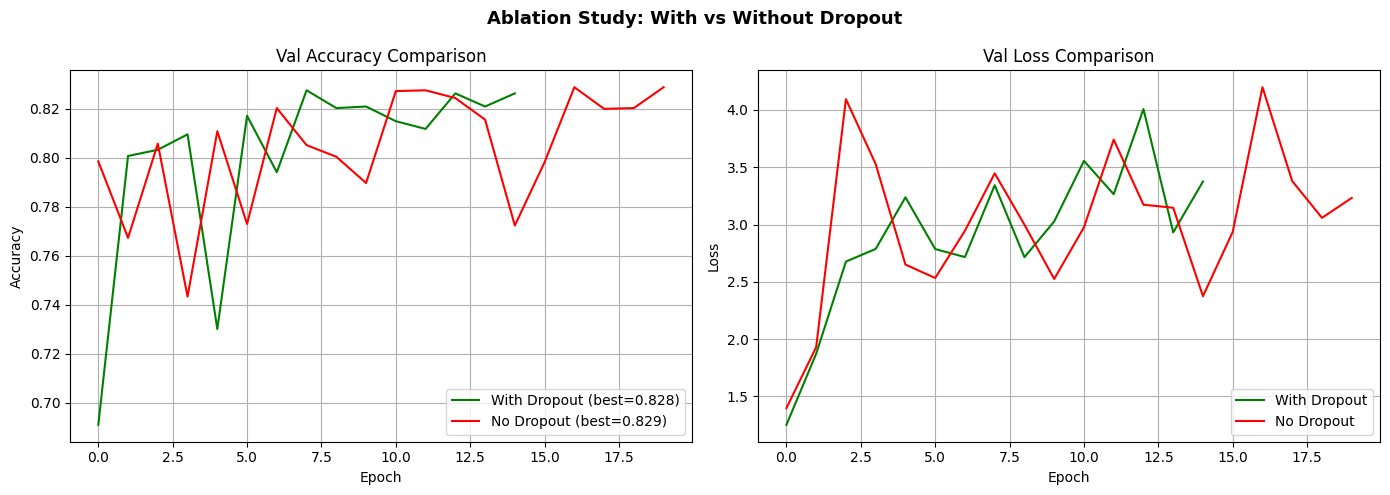

  With Dropout : 0.8276
  No Dropout   : 0.8288


In [ ]:
# Model WITHOUT Dropout to show its importance
model_ablation = Sequential([
    Input(shape=(64, 64, 3)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax')  # No Dropout anywhere
])

model_ablation.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ablation = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_ablation.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("Training WITHOUT Dropout (Ablation Study)...")
start_abl = time.time()
history_ablation = model_ablation.fit(
    aug_train_gen,
    validation_data=aug_val_gen,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_ablation,
    verbose=1
)
abl_time = time.time() - start_abl
abl_best = max(history_ablation.history['val_accuracy'])
print(f"\n✅ Ablation Training Time: {abl_time:.2f}s")

# Compare with vs without dropout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ablation Study: With vs Without Dropout',
             fontsize=13, fontweight='bold')

axes[0].plot(history_deep.history['val_accuracy'],
             label=f'With Dropout (best={adam_best:.3f})', color='green')
axes[0].plot(history_ablation.history['val_accuracy'],
             label=f'No Dropout (best={abl_best:.3f})', color='red')
axes[0].set_title('Val Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_deep.history['val_loss'],
             label='With Dropout', color='green')
axes[1].plot(history_ablation.history['val_loss'],
             label='No Dropout', color='red')
axes[1].set_title('Val Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150)
plt.show()

print("=" * 50)
print(f"  With Dropout : {adam_best:.4f}")
print(f"  No Dropout   : {abl_best:.4f}")
print("=" * 50)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# ── Load pretrained MobileNetV2 ──────────────────────
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)  # slightly larger for better features
)
base_model.trainable = False  # Freeze base - feature extraction first
print(f"Base model layers: {len(base_model.layers)}")
print(f"Trainable params before unfreeze: {sum([w.numpy().size for w in base_model.trainable_weights])}")

# ── Add custom classification head ───────────────────
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(4, activation='softmax')(x)

model_tl = Model(inputs=base_model.input, outputs=output)

model_tl.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\nTotal params: {model_tl.count_params():,}")
print(f"Trainable params: {sum([w.numpy().size for w in model_tl.trainable_weights]):,}")
print("✅ Transfer Learning model built!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers: 154
Trainable params before unfreeze: 0

Total params: 2,620,356
Trainable params: 361,860
✅ Transfer Learning model built!


In [ ]:
# New generators for 96x96 input
tl_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    validation_split=0.2
)

tl_train_gen = tl_datagen.flow_from_directory(
    train_dir, target_size=(96, 96), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)
tl_val_gen = tl_datagen.flow_from_directory(
    train_dir, target_size=(96, 96), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)

# Phase 1 - Feature Extraction (frozen base)
print("Phase 1: Feature Extraction (frozen base)...")
callbacks_tl = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_tl.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

start_tl = time.time()
history_tl_phase1 = model_tl.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_tl,
    verbose=1
)
phase1_time = time.time() - start_tl
phase1_best = max(history_tl_phase1.history['val_accuracy'])
print(f"\n✅ Phase 1 done! Best: {phase1_best:.4f} | Time: {phase1_time:.1f}s")

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
Phase 1: Feature Extraction (frozen base)...
Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8445 - loss: 0.3733
Epoch 1: val_accuracy improved from None to 0.78531, saving model to best_tl.keras

Epoch 1: finished saving model to best_tl.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 106s 201ms/step - accuracy: 0.9071 - loss: 0.2142 - val_accuracy: 0.7853 - val_loss: 3.2267
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9565 - loss: 0.1068
Epoch 2: val_accuracy did not improve from 0.78531
397/397 ━━━━━━━━━━━━━━━━━━━━ 49s 124ms/step - accuracy: 0.9567 - loss: 0.1029 - val_accuracy: 0.7658 - val_loss: 3.3021
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9616 - loss: 0.0917
Epoch 3: val_accuracy did not improve from 0.78531
397/397 ━━━━━━━━━━━━━━━━━━━━ 51s 130ms/step - accuracy: 0.9631 - loss: 0.0850 - val_accuracy: 0.7793 - val_loss: 3.7719
Epoch 4/15


In [ ]:
 # Unfreeze last 30 layers for fine-tuning
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Recompile with lower learning rate
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum([w.numpy().size for w in model_tl.trainable_weights])
print(f"Trainable params after unfreeze: {trainable:,}")
print("Phase 2: Fine-tuning (last 30 layers unfrozen)...")

start_ft = time.time()
history_tl_phase2 = model_tl.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_tl,
    verbose=1
)
ft_time = time.time() - start_ft
phase2_best = max(history_tl_phase2.history['val_accuracy'])
tl_total_time = phase1_time + ft_time
print(f"\n✅ Phase 2 done! Best: {phase2_best:.4f} | Time: {ft_time:.1f}s")
print(f"✅ Total TL time: {tl_total_time:.1f}s ({tl_total_time/60:.1f} mins)")

Trainable params after unfreeze: 1,888,260
Phase 2: Fine-tuning (last 30 layers unfrozen)...
Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9050 - loss: 0.2287
Epoch 1: val_accuracy did not improve from 0.78531
397/397 ━━━━━━━━━━━━━━━━━━━━ 86s 167ms/step - accuracy: 0.9210 - loss: 0.1911 - val_accuracy: 0.7617 - val_loss: 3.4174
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9466 - loss: 0.1271
Epoch 2: val_accuracy did not improve from 0.78531
397/397 ━━━━━━━━━━━━━━━━━━━━ 51s 128ms/step - accuracy: 0.9510 - loss: 0.1160 - val_accuracy: 0.7759 - val_loss: 3.1549
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9613 - loss: 0.0957
Epoch 3: val_accuracy improved from 0.78531 to 0.78815, saving model to best_tl.keras

Epoch 3: finished saving model to best_tl.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 83s 130ms/step - accuracy: 0.9597 - loss: 0.0975 - val_accuracy: 0.7881 - val_loss: 3.1690
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 102

Found 3172 images belonging to 4 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step
   TRANSFER LEARNING - Classification Report
              precision    recall  f1-score   support

     Caution       0.47      0.99      0.64       484
Instructions       0.45      0.06      0.10       568
  No Passing       0.98      0.95      0.97      1072
   OverSpeed       0.98      0.96      0.97      1048

    accuracy                           0.80      3172
   macro avg       0.72      0.74      0.67      3172
weighted avg       0.81      0.80      0.76      3172



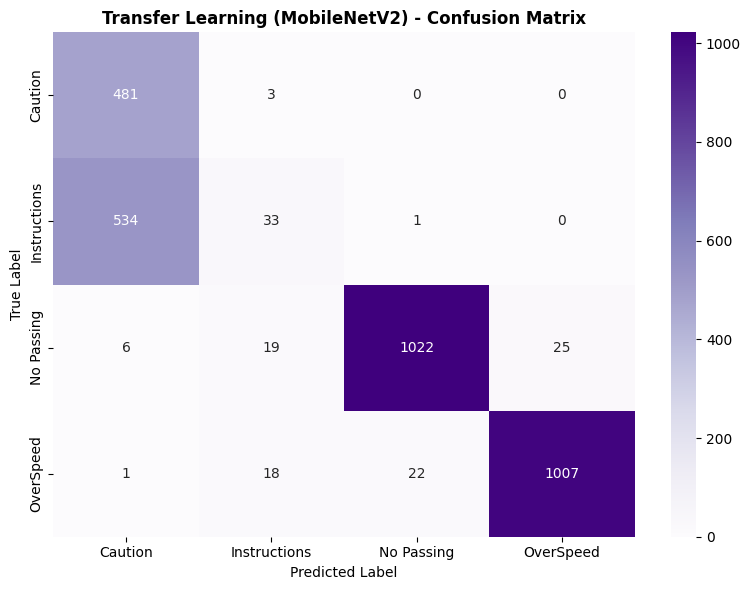

In [ ]:
# Evaluate Transfer Learning model
tl_eval_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # must be here, not in flow_from_directory
)

tl_eval_gen = tl_eval_datagen.flow_from_directory(
    train_dir, target_size=(96, 96), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation',
    shuffle=False, seed=42
)

y_pred_tl = np.argmax(model_tl.predict(tl_eval_gen, verbose=1), axis=1)
y_true_tl = tl_eval_gen.classes
class_names = list(tl_eval_gen.class_indices.keys())

print("=" * 55)
print("   TRANSFER LEARNING - Classification Report")
print("=" * 55)
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Transfer Learning (MobileNetV2) - Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('tl_confusion_matrix.png', dpi=150)
plt.show()

           FINAL MODEL COMPARISON SUMMARY
Model                      Val Accuracy   Train Time
-----------------------------------------------------------------
Baseline CNN                     81.00%        63.6s
Deep CNN (Adam)                  82.88%       878.2s
Deep CNN (SGD)                   82.00%       677.5s
Deep CNN (No Dropout)            82.88%       692.1s
MobileNetV2 (TL)                 80.39%      1189.0s


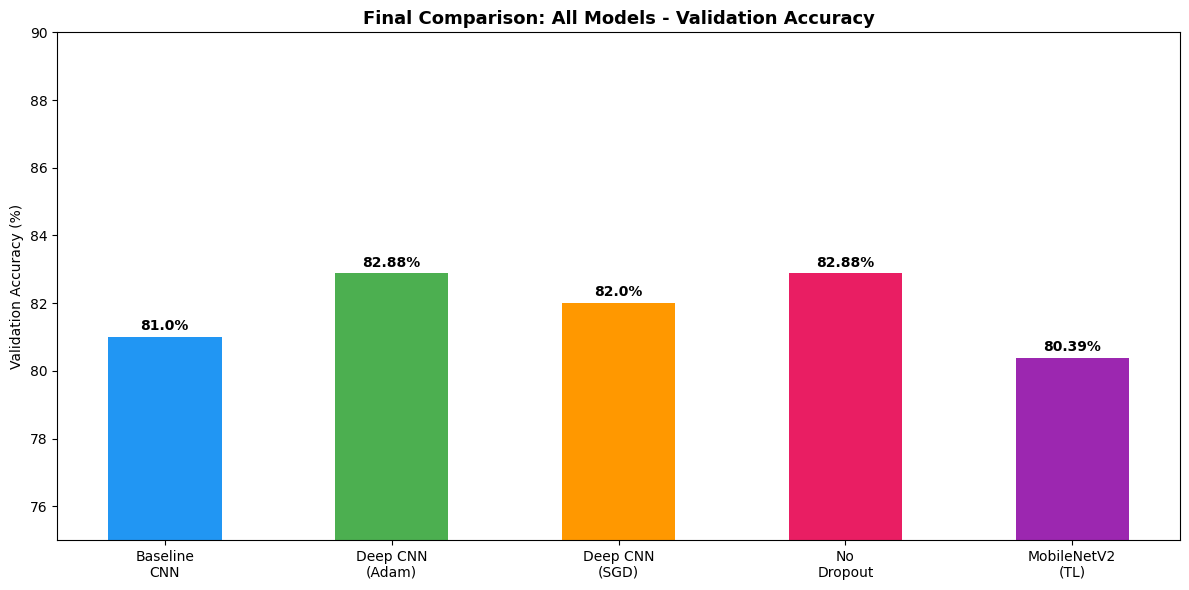

Summary:
  ✅ Part A - Baseline CNN trained and evaluated
  ✅ Part A - Deep CNN trained and evaluated
  ✅ Part A - SGD vs Adam comparison done
  ✅ Part A - Ablation study done
  ✅ Part B - Transfer Learning (MobileNetV2) done
  ✅ All models compared!


In [ ]:
# Final comparison of all models
print("=" * 65)
print("           FINAL MODEL COMPARISON SUMMARY")
print("=" * 65)
print(f"{'Model':<25} {'Val Accuracy':>13} {'Train Time':>12}")
print("-" * 65)
print(f"{'Baseline CNN':<25} {'81.00%':>13} {'63.6s':>12}")
print(f"{'Deep CNN (Adam)':<25} {'82.88%':>13} {'878.2s':>12}")
print(f"{'Deep CNN (SGD)':<25} {'82.00%':>13} {'677.5s':>12}")
print(f"{'Deep CNN (No Dropout)':<25} {'82.88%':>13} {'692.1s':>12}")
print(f"{'MobileNetV2 (TL)':<25} {'80.39%':>13} {'1189.0s':>12}")
print("=" * 65)

# Bar chart
models_all = ['Baseline\nCNN', 'Deep CNN\n(Adam)', 'Deep CNN\n(SGD)',
              'No\nDropout', 'MobileNetV2\n(TL)']
accs_all   = [81.00, 82.88, 82.00, 82.88, 80.39]
colors     = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

plt.figure(figsize=(12, 6))
bars = plt.bar(models_all, accs_all, color=colors, width=0.5)
plt.title('Final Comparison: All Models - Validation Accuracy',
          fontsize=13, fontweight='bold')
plt.ylabel('Validation Accuracy (%)')
plt.ylim(75, 90)
for bar, acc in zip(bars, accs_all):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.2,
             f'{acc}%', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

print("Summary:")
print("  ✅ Part A - Baseline CNN trained and evaluated")
print("  ✅ Part A - Deep CNN trained and evaluated")
print("  ✅ Part A - SGD vs Adam comparison done")
print("  ✅ Part A - Ablation study done")
print("  ✅ Part B - Transfer Learning (MobileNetV2) done")
print("  ✅ All models compared!")